# TS-SatFire: Wildfire Burned Area Mapping with LightUNet

**Dataset:** Zhao et al. (2025), *Scientific Data* 12:1817  
**Task:** Burned Area (BA) binary segmentation from VIIRS time-series  
**Model:** LightUNet — lightweight U-Net with 4-level encoder-decoder  
**Environment:** Kaggle T4 x2 GPU

---

## Dataset Summary

- 179 wildfire events, contiguous US, January 2017 to October 2021
- 3552 VIIRS surface reflectance images + auxiliary data (71 GB total)
- 27 input channels per timestep (6 spectral + 2 thermal night + 19 auxiliary)
- Three tasks: Active Fire Detection, Burned Area Mapping, Fire Progression Prediction
- This notebook focuses on **Burned Area Mapping** using 4-timestep windows

### Channel Layout (26 used per timestep)

| Index | Source | Description |
|-------|--------|-------------|
| 0 | VIIRS_Day | Band I1 (Red, 0.64 um) |
| 1 | VIIRS_Day | Band I2 (NIR, 0.86 um) |
| 2 | VIIRS_Day | Band I3 (SWIR, 1.61 um) |
| 3 | VIIRS_Day | Band I4 (MIR, 3.74 um) — cummax aggregated for BA |
| 4 | VIIRS_Day | Band I5 (LWIR, 11.45 um) — cummax aggregated for BA |
| 5 | VIIRS_Day | Band M11 (SWIR, 2.25 um) |
| 6 | VIIRS_Night | Band I4 Night — cummax aggregated |
| 7 | VIIRS_Night | Band I5 Night — cummax aggregated |
| 8-25 | FirePred | Auxiliary: NDVI, EVI, weather, topography, land cover, forecasts |

### Preprocessing (paper Section Methods)
For BA task, thermal bands I4/I5 (day and night) are replaced with their **cumulative pixel-wise maximum** from fire start through the current timestep. This highlights the total burn scar signature accumulated over the fire lifecycle.

In [1]:
import os
import sys
import glob
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {props.name}  {props.total_memory // 1024**2} MB')

Python  : 3.12.12
PyTorch : 2.9.0+cu126
CUDA    : True
  GPU 0: Tesla T4  14912 MB
  GPU 1: Tesla T4  14912 MB


## Configuration

All key hyperparameters are defined here. For the demo (3-epoch run under 1 hour), the defaults below are appropriate. For a full training run matching paper performance, set `NUM_EPOCHS = 30` and `TRAIN_INTERVAL = 2`.

In [2]:
# ---------------------------------------------------------------
# Paths
# ---------------------------------------------------------------
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
CKPT_PATH  = os.path.join(OUTPUT_DIR, 'lightunet_ba_best.pt')
STATS_PATH = os.path.join(OUTPUT_DIR, 'norm_stats.npz')
META_PATH  = os.path.join(OUTPUT_DIR, 'run_meta.json')

# ---------------------------------------------------------------
# Model / data
# ---------------------------------------------------------------
TIME_STEPS      = 4        # number of consecutive days per sample
CHANS_PER_STEP  = 26       # channels per timestep
IN_CHANNELS     = CHANS_PER_STEP * TIME_STEPS   # 104
PATCH_SIZE      = 64       # spatial crop during training
BASE_CH         = 32       # U-Net base feature size

# ---------------------------------------------------------------
# Training
# ---------------------------------------------------------------
NUM_EPOCHS      = 10       # increase to 30 for full run (~4-5 hours)
BATCH_SIZE      = 8
LR              = 3e-4
WEIGHT_DECAY    = 1e-5
TRAIN_INTERVAL  = 4        # window sampling stride (larger = fewer samples = faster)
VAL_INTERVAL    = 4
SEED            = 42

# ---------------------------------------------------------------
# Inference flags -- all outputs saved so notebook can be closed
# ---------------------------------------------------------------
SAVE_PREDICTIONS = True    # save per-sample numpy predictions after test eval
SAVE_FIGURES     = True    # save all figures as PNG

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_autocast():
    return torch.amp.autocast('cuda') if device.type == 'cuda' \
           else torch.amp.autocast('cpu', dtype=torch.float32)

print(f'Device         : {device}')
print(f'TIME_STEPS     : {TIME_STEPS}')
print(f'IN_CHANNELS    : {IN_CHANNELS}')
print(f'NUM_EPOCHS     : {NUM_EPOCHS}')
print(f'TRAIN_INTERVAL : {TRAIN_INTERVAL}')
print(f'PATCH_SIZE     : {PATCH_SIZE}')

Device         : cuda
TIME_STEPS     : 4
IN_CHANNELS    : 104
NUM_EPOCHS     : 10
TRAIN_INTERVAL : 4
PATCH_SIZE     : 64


## Dataset Discovery and Splits

Fire IDs containing '2021' form the test set (burned area and progression prediction tasks). Fires from 2017-2020 are split into train (90%) and validation (10%) following the paper's protocol.

In [3]:
# ---------------------------------------------------------------
# Locate and validate fire directories
# ---------------------------------------------------------------
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])

REQUIRED = {'VIIRS_Day', 'VIIRS_Night', 'FirePred'}

fire_dirs = []
invalid   = []
for d in all_dirs:
    sub = set(os.listdir(d))
    if REQUIRED.issubset(sub):
        fire_dirs.append(d)
    else:
        invalid.append(os.path.basename(d))

print(f'Total folders   : {len(all_dirs)}')
print(f'Valid fires     : {len(fire_dirs)}')
print(f'Invalid (skip)  : {len(invalid)}')

# ---------------------------------------------------------------
# Remove fires with non-standard FirePred channel count
# ---------------------------------------------------------------
def fp_chan_count(fd):
    files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
    if not files:
        return -1
    with rasterio.open(files[0]) as src:
        return src.count

bad = [fd for fd in fire_dirs if fp_chan_count(fd) != 19]
bad_set   = set(bad)
fire_dirs = [fd for fd in fire_dirs if fd not in bad_set]
print(f'Removed non-standard FirePred fires: {len(bad)}')
print(f'Usable fires    : {len(fire_dirs)}')

# ---------------------------------------------------------------
# Train / val / test split
# ---------------------------------------------------------------
random.seed(SEED)
test_fires  = [fd for fd in fire_dirs if '2021' in os.path.basename(fd)]
train_pool  = [fd for fd in fire_dirs if fd not in set(test_fires)]
random.shuffle(train_pool)
n_val       = max(1, int(len(train_pool) * 0.10))
val_fires   = train_pool[:n_val]
train_fires = train_pool[n_val:]

print(f'\nSplit summary:')
print(f'  train : {len(train_fires)} fires')
print(f'  val   : {len(val_fires)} fires')
print(f'  test  : {len(test_fires)} fires')
print(f'  total : {len(fire_dirs)} fires')

Total folders   : 192
Valid fires     : 178
Invalid (skip)  : 14
Removed non-standard FirePred fires: 5
Usable fires    : 173

Split summary:
  train : 135 fires
  val   : 14 fires
  test  : 24 fires
  total : 173 fires


## Exploratory Data Analysis

Survey key statistics across the full dataset: timesteps per fire, spatial dimensions, BA label coverage, and missing value rates per channel.

Surveying fires:   0%|          | 0/173 [00:00<?, ?it/s]

      n_days         ba_pos_days        
        mean min max        mean min max
split                                   
test    35.6  10  87        21.2   1  70
train   17.8   3  65         9.2   0  36
val     17.8   7  41         8.7   1  31


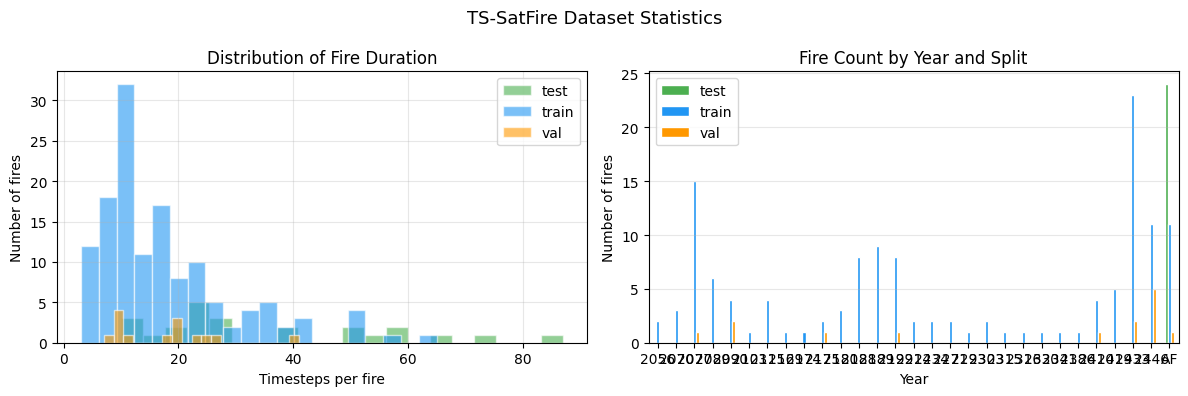

EDA complete.


In [4]:
# ---------------------------------------------------------------
# Survey fires: timesteps, shape, BA coverage
# ---------------------------------------------------------------
records = []
for fd in tqdm(fire_dirs, desc='Surveying fires'):
    fid       = os.path.basename(fd)
    day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    fp_files  = sorted(glob.glob(os.path.join(fd, 'FirePred',  '*.tif')))
    year      = fid[:4] if fid[:4].isdigit() else 'AF'
    n_days    = len(day_files)

    # Spatial size from first day file
    with rasterio.open(day_files[0]) as src:
        h, w = src.height, src.width

    # BA positive days
    ba_pos = 0
    for fp in fp_files:
        with rasterio.open(fp) as src:
            ch2 = src.read(3).astype(np.float32)
        if (ch2 > 0).any():
            ba_pos += 1

    split = 'test'  if fd in set(test_fires)  else \
            'val'   if fd in set(val_fires)    else 'train'

    records.append({'fire_id': fid, 'year': year, 'split': split,
                    'n_days': n_days, 'height': h, 'width': w,
                    'ba_pos_days': ba_pos})

df = pd.DataFrame(records)
print(df.groupby('split')[['n_days', 'ba_pos_days']].agg(['mean','min','max']).round(1))

# ---------------------------------------------------------------
# Visualise distribution of timesteps per fire
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}
for split, grp in df.groupby('split'):
    axes[0].hist(grp['n_days'], bins=20, alpha=0.6,
                 color=colors[split], label=split, edgecolor='white')
axes[0].set_xlabel('Timesteps per fire')
axes[0].set_ylabel('Number of fires')
axes[0].set_title('Distribution of Fire Duration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

year_counts = df.groupby(['year', 'split']).size().unstack(fill_value=0)
year_counts.plot(kind='bar', ax=axes[1], color=[colors[s] for s in year_counts.columns],
                 edgecolor='white')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of fires')
axes[1].set_title('Fire Count by Year and Split')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

plt.suptitle('TS-SatFire Dataset Statistics', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'eda_stats.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete.')

## Normalisation Statistics

Per-channel mean and standard deviation are computed from a subset of training fires and saved to disk. On subsequent runs the saved stats are loaded directly.

Computing normalisation statistics...


Computing stats:   0%|          | 0/25 [00:00<?, ?it/s]

Saved to /kaggle/working/norm_stats.npz
Means range: [-0.171, 4323.154]
Stds  range: [0.002,  2476.802]


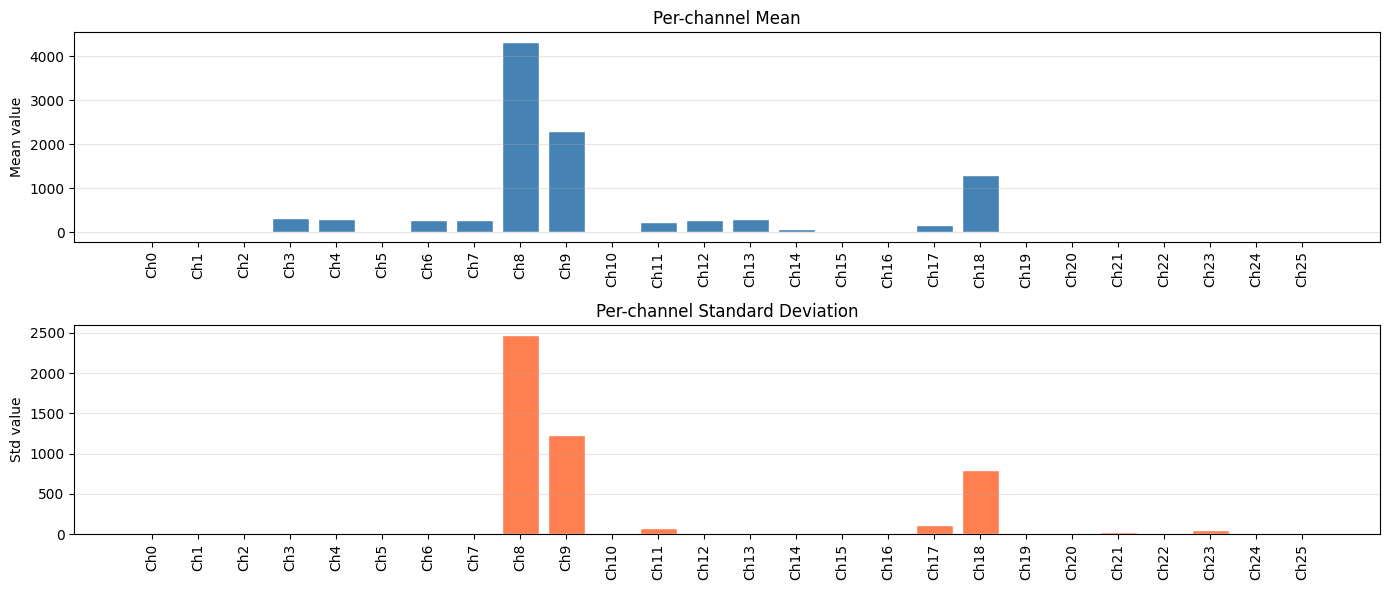

In [5]:
# ---------------------------------------------------------------
# Compute or load normalisation statistics
# ---------------------------------------------------------------
def compute_norm_stats(fire_dirs, n_fires=25, n_days=3, seed=SEED):
    rng    = random.Random(seed)
    sample = rng.sample(fire_dirs, min(n_fires, len(fire_dirs)))
    sums   = np.zeros(CHANS_PER_STEP, dtype=np.float64)
    sq_sums= np.zeros(CHANS_PER_STEP, dtype=np.float64)
    counts = np.zeros(CHANS_PER_STEP, dtype=np.float64)

    for fd in tqdm(sample, desc='Computing stats'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            date_str   = os.path.basename(dp).replace('_VIIRS_Day.tif', '')
            night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')

            with rasterio.open(dp) as src:
                d = src.read().astype(np.float32)   # (8, H, W)
            spectral = d[:6]

            night = np.full((2, d.shape[1], d.shape[2]), np.nan, np.float32)
            if os.path.exists(night_path):
                with rasterio.open(night_path) as src:
                    night = src.read().astype(np.float32)[:2]

            H, W = spectral.shape[1], spectral.shape[2]
            if os.path.exists(fp_path):
                with rasterio.open(fp_path) as src:
                    fp = src.read().astype(np.float32)
                fp_t = torch.from_numpy(fp).unsqueeze(0)
                fp_t = F.interpolate(fp_t, size=(H, W), mode='nearest')
                fp   = fp_t.squeeze(0).numpy()
                aux  = np.concatenate([fp[:2], fp[3:]], axis=0)  # (18, H, W)
            else:
                aux = np.zeros((18, H, W), np.float32)

            frame = np.concatenate([spectral, night, aux], axis=0)  # (26, H, W)
            for c in range(CHANS_PER_STEP):
                vals = frame[c][np.isfinite(frame[c])]
                sums[c]    += vals.sum()
                sq_sums[c] += (vals ** 2).sum()
                counts[c]  += vals.size

    means = (sums   / np.maximum(counts, 1)).astype(np.float32)
    stds  = np.sqrt(np.maximum(sq_sums / np.maximum(counts, 1) - means ** 2,
                               1e-6)).astype(np.float32)
    return means, stds

if os.path.exists(STATS_PATH):
    data       = np.load(STATS_PATH)
    CHAN_MEANS  = data['means']
    CHAN_STDS   = data['stds']
    print(f'Loaded normalisation stats from {STATS_PATH}')
else:
    print('Computing normalisation statistics...')
    CHAN_MEANS, CHAN_STDS = compute_norm_stats(train_fires)
    np.savez(STATS_PATH, means=CHAN_MEANS, stds=CHAN_STDS)
    print(f'Saved to {STATS_PATH}')

print(f'Means range: [{CHAN_MEANS.min():.3f}, {CHAN_MEANS.max():.3f}]')
print(f'Stds  range: [{CHAN_STDS.min():.3f},  {CHAN_STDS.max():.3f}]')

# Plot channel statistics
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
ch_labels = [f'Ch{i}' for i in range(CHANS_PER_STEP)]
axes[0].bar(ch_labels, CHAN_MEANS, color='steelblue', edgecolor='white')
axes[0].set_title('Per-channel Mean')
axes[0].set_ylabel('Mean value')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(ch_labels, CHAN_STDS, color='coral', edgecolor='white')
axes[1].set_title('Per-channel Standard Deviation')
axes[1].set_ylabel('Std value')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'channel_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

## Dataset Class

`TSSatFireDataset` handles:
- Time-window sampling with configurable stride
- Thermal band cumulative-max aggregation (BA preprocessing from paper)
- Spatial crop to minimum size across window frames
- Auxiliary data (FirePred) resize to VIIRS resolution
- Per-channel normalisation
- Random crop and flip augmentation during training

In [6]:
class TSSatFireDataset(Dataset):

    def __init__(self, fire_dirs, task='ba', time_steps=TIME_STEPS,
                 interval=1, patch_size=PATCH_SIZE,
                 means=None, stds=None, augment=False):
        self.task       = task
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.augment    = augment
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        skipped = 0
        for fd in fire_dirs:
            fp_files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
            if fp_files:
                with rasterio.open(fp_files[0]) as src:
                    if src.count != 19:
                        skipped += 1
                        continue
            day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
            if len(day_files) < self.T:
                skipped += 1
                continue
            n = len(day_files)
            start = 0
            while start + self.T <= n:
                self.samples.append({
                    'fire_dir'  : fd,
                    'day_files' : day_files,
                    'start'     : start,
                    'end'       : start + self.T - 1,
                })
                start += self.interval
        print(f'Dataset: {len(self.samples)} samples '
              f'(T={self.T}, interval={self.interval}, skipped={skipped})')

    @staticmethod
    def _date(path):
        return os.path.basename(path).replace('_VIIRS_Day.tif', '')

    def _load_timestep(self, fd, day_path, H, W):
        date_str   = self._date(day_path)
        night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
        fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')

        with rasterio.open(day_path) as src:
            day_arr  = src.read().astype(np.float32)
        spectral = day_arr[:6, :H, :W]

        if os.path.exists(night_path):
            with rasterio.open(night_path) as src:
                night = src.read().astype(np.float32)[:2, :H, :W]
        else:
            night = np.full((2, H, W), np.nan, np.float32)

        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                fp = src.read().astype(np.float32)
            if fp.shape[1] != H or fp.shape[2] != W:
                fp = F.interpolate(torch.from_numpy(fp).unsqueeze(0),
                                   size=(H, W), mode='nearest').squeeze(0).numpy()
            aux = np.concatenate([fp[:2], fp[3:]], axis=0)  # (18, H, W)
        else:
            aux = np.zeros((18, H, W), np.float32)

        return np.concatenate([spectral, night, aux], axis=0)  # (26, H, W)

    def _load_label(self, fd, day_path, H, W):
        date_str = self._date(day_path)
        if self.task == 'af':
            with rasterio.open(day_path) as src:
                ch6 = src.read(7).astype(np.float32)
            return (~np.isnan(ch6[:H, :W])).astype(np.float32)
        else:
            fp_path = os.path.join(fd, 'FirePred', f'{date_str}_FirePred.tif')
            if os.path.exists(fp_path):
                with rasterio.open(fp_path) as src:
                    ch2 = src.read(3).astype(np.float32)
                if ch2.shape[0] != H or ch2.shape[1] != W:
                    ch2 = F.interpolate(
                        torch.from_numpy(ch2).unsqueeze(0).unsqueeze(0),
                        size=(H, W), mode='nearest').squeeze().numpy()
                return (ch2 > 0).astype(np.float32)
            return np.zeros((H, W), np.float32)

    def _thermal_cummax(self, fd, all_day_files, win_end, H, W):
        history = []
        for i in range(win_end + 1):
            dp       = all_day_files[i]
            date_str = self._date(dp)
            np_path  = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            with rasterio.open(dp) as src:
                i4d = src.read(4).astype(np.float32)[:H, :W]
                i5d = src.read(5).astype(np.float32)[:H, :W]
            if os.path.exists(np_path):
                with rasterio.open(np_path) as src:
                    i4n = src.read(1).astype(np.float32)[:H, :W]
                    i5n = src.read(2).astype(np.float32)[:H, :W]
            else:
                i4n = np.full((H, W), np.nan, np.float32)
                i5n = np.full((H, W), np.nan, np.float32)
            history.append(np.stack([i4d, i5d, i4n, i5n]))
        return history

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        all_files = s['day_files']
        win_start = s['start']
        win_end   = s['end']
        win_files = all_files[win_start : win_end + 1]

        # Common spatial size
        shapes    = []
        for dp in win_files:
            with rasterio.open(dp) as src:
                shapes.append((src.height, src.width))
        H = min(s[0] for s in shapes)
        W = min(s[1] for s in shapes)

        frames = [self._load_timestep(fd, dp, H, W) for dp in win_files]

        # BA thermal cumulative max aggregation
        if self.task == 'ba':
            history = self._thermal_cummax(fd, all_files, win_end, H, W)
            for t in range(self.T):
                gd     = win_start + t
                cmx    = np.nanmax(np.stack(history[:gd + 1]), axis=0)
                frames[t][3] = cmx[0]
                frames[t][4] = cmx[1]
                frames[t][6] = cmx[2]
                frames[t][7] = cmx[3]

        stack = np.stack(frames, axis=0)   # (T, 26, H, W)

        # Normalise
        if self.means is not None:
            stack = (stack - self.means[None, :, None, None]) / \
                     self.stds[ None, :, None, None]

        stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)
        label = self._load_label(fd, win_files[-1], H, W)

        # Random crop
        if self.patch_size and H > self.patch_size and W > self.patch_size:
            r = random.randint(0, H - self.patch_size)
            c = random.randint(0, W - self.patch_size)
            p = self.patch_size
            stack = stack[:, :, r:r+p, c:c+p]
            label = label[r:r+p, c:c+p]

        # Random flip augmentation
        if self.augment:
            if random.random() > 0.5:
                stack = stack[:, :, :, ::-1].copy()
                label = label[:,    ::-1].copy()
            if random.random() > 0.5:
                stack = stack[:, :, ::-1, :].copy()
                label = label[::-1, :   ].copy()

        # (T, 26, H, W) -> (26*T, H, W)
        x = torch.from_numpy(
            stack.reshape(-1, stack.shape[2], stack.shape[3])).float()
        y = torch.from_numpy(label).long()
        return x, y

print('TSSatFireDataset defined.')

TSSatFireDataset defined.


## Dataloaders

- Training: patch-based (64x64), stride=4, shuffle, augmentation enabled
- Validation: patch-based, stride=4, no augmentation  
- Test: full-size images (patch_size=None), stride=4, batch=1

In [7]:
train_ds = TSSatFireDataset(
    fire_dirs  = train_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = TRAIN_INTERVAL,
    patch_size = PATCH_SIZE,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    augment    = True,
)
val_ds = TSSatFireDataset(
    fire_dirs  = val_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = PATCH_SIZE,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    augment    = False,
)
test_ds = TSSatFireDataset(
    fire_dirs  = test_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = None,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    augment    = False,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')
print(f'Test  samples         : {len(test_ds)}')

# Verify batch shapes
x, y = next(iter(train_loader))
print(f'\nBatch x shape : {x.shape}   dtype={x.dtype}')
print(f'Batch y shape : {y.shape}   dtype={y.dtype}')
print(f'Label unique  : {y.unique().tolist()}')

Dataset: 548 samples (T=4, interval=4, skipped=1)
Dataset: 57 samples (T=4, interval=4, skipped=0)
Dataset: 202 samples (T=4, interval=4, skipped=0)
Train batches / epoch : 68
Val   batches / epoch : 8
Test  samples         : 202

Batch x shape : torch.Size([8, 104, 64, 64])   dtype=torch.float32
Batch y shape : torch.Size([8, 64, 64])   dtype=torch.int64
Label unique  : [0]


## Model: LightUNet

A 4-level encoder-decoder U-Net with skip connections. The model takes a flattened time-channel tensor of shape `(B, 26*T, H, W)` and outputs class logits `(B, 2, H, W)`.

- `base_ch=32` gives approximately 7.8M parameters
- No spatial dimension constraints (unlike SwinUNETR which requires multiples of 32)
- Deployed across both T4 GPUs with DataParallel

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class LightUNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, out_channels=2, base_ch=BASE_CH):
        super().__init__()
        b = base_ch
        self.enc1 = DoubleConv(in_channels, b)
        self.enc2 = DoubleConv(b,    b * 2)
        self.enc3 = DoubleConv(b*2,  b * 4)
        self.enc4 = DoubleConv(b*4,  b * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(b*8, b*16)
        self.up4  = nn.ConvTranspose2d(b*16, b*8,  2, stride=2)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4,  2, stride=2)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2,  2, stride=2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,    2, stride=2)
        self.dec4 = DoubleConv(b*16, b*8)
        self.dec3 = DoubleConv(b*8,  b*4)
        self.dec2 = DoubleConv(b*4,  b*2)
        self.dec1 = DoubleConv(b*2,  b)
        self.head = nn.Conv2d(b, out_channels, 1)

    def _pad_cat(self, up, skip):
        if up.shape != skip.shape:
            up = F.interpolate(up, size=skip.shape[2:], mode='bilinear',
                               align_corners=False)
        return torch.cat([up, skip], dim=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(self._pad_cat(self.up4(b),  e4))
        d3 = self.dec3(self._pad_cat(self.up3(d4), e3))
        d2 = self.dec2(self._pad_cat(self.up2(d3), e2))
        d1 = self.dec1(self._pad_cat(self.up1(d2), e1))
        return self.head(d1)


model = LightUNet(in_channels=IN_CHANNELS, out_channels=2, base_ch=BASE_CH)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LightUNet parameters : {n_params:,}')

# Dry run
with torch.no_grad():
    dummy = torch.zeros(2, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE, device=device)
    out   = model(dummy)
print(f'Dry run: input {tuple(dummy.shape)} -> output {tuple(out.shape)}')

LightUNet parameters : 7,792,162
Dry run: input (2, 104, 64, 64) -> output (2, 2, 64, 64)


## Loss Function and Metrics

**Loss:** Dice Loss on the fire class only. Computed as `1 - (2*TP) / (2*TP + FP + FN)`.  
**Metrics:** Pixel-wise F1 and IoU accumulated across all batches.

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: (B, 2, H, W)  targets: (B, H, W) int64
        prob  = torch.softmax(logits, dim=1)[:, 1]  # fire class prob
        tgt   = (targets == 1).float()
        inter = (prob * tgt).sum()
        denom = prob.sum() + tgt.sum() + self.smooth
        return 1.0 - (2.0 * inter + self.smooth) / denom


class FireMetrics:
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = 0

    def update(self, logits, targets):
        prob = torch.softmax(logits.float(), dim=1)[:, 1]
        pred = (prob > self.threshold).long()
        tgt  = (targets == 1).long()
        self.tp += int((pred * tgt).sum())
        self.fp += int((pred * (1 - tgt)).sum())
        self.fn += int(((1 - pred) * tgt).sum())

    def report(self):
        tp, fp, fn = self.tp, self.fp, self.fn
        f1  = 2*tp / (2*tp + fp + fn + 1e-6)
        iou = tp   / (tp  + fp + fn + 1e-6)
        return {'F1': f1, 'IoU': iou, 'TP': tp, 'FP': fp, 'FN': fn}


criterion = DiceLoss(smooth=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = GradScaler('cuda') if device.type == 'cuda' else None

print('Loss, optimizer, scheduler and AMP scaler ready.')

Loss, optimizer, scheduler and AMP scaler ready.


## Training and Validation Functions

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    metrics  = FireMetrics()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        bar = tqdm(loader, leave=False,
                   desc='Train' if train else 'Val  ')
        for x, y in bar:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            with make_autocast():
                logits = model(x)
                loss   = criterion(logits, y)
            if train:
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
            metrics.update(logits, y)
            total_loss += loss.item()
            rep = metrics.report()
            bar.set_postfix(loss=f'{loss.item():.4f}',
                            F1=f'{rep["F1"]:.3f}')
    rep = metrics.report()
    return total_loss / len(loader), rep['F1'], rep['IoU']

print('run_epoch defined.')

run_epoch defined.


## Training Loop

The best checkpoint (by validation F1) is saved to disk continuously. If the notebook is interrupted, the best weights are preserved. Training history is also saved as JSON for later plotting.

In [11]:
history = {
    'train_loss': [], 'train_F1': [], 'train_IoU': [],
    'val_loss':   [], 'val_F1':   [], 'val_IoU':   [],
    'lr':         [],
}

best_val_f1 = 0.0
print(f'Training for {NUM_EPOCHS} epochs')
print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_f1, tr_iou = run_epoch(train_loader, train=True)
    vl_loss, vl_f1, vl_iou = run_epoch(val_loader,   train=False)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['train_F1'  ].append(tr_f1)
    history['train_IoU' ].append(tr_iou)
    history['val_loss'  ].append(vl_loss)
    history['val_F1'    ].append(vl_f1)
    history['val_IoU'   ].append(vl_iou)
    history['lr'        ].append(current_lr)

    tag = ''
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        # Save bare model weights (unwrap DataParallel if present)
        state = model.module.state_dict() if hasattr(model, 'module') \
                else model.state_dict()
        torch.save(state, CKPT_PATH)
        tag = '  [best]'

    print(f'Ep {epoch:3d}/{NUM_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_F1={tr_f1:.4f}  '
          f'train_IoU={tr_iou:.4f}  '
          f'val_loss={vl_loss:.4f}  val_F1={vl_f1:.4f}  '
          f'val_IoU={vl_iou:.4f}  lr={current_lr:.2e}{tag}')

    # Save history after every epoch so it survives a crash
    with open(os.path.join(OUTPUT_DIR, 'history.json'), 'w') as f:
        json.dump(history, f)

print(f'\nTraining complete.')
print(f'Best val F1  : {best_val_f1:.4f}')
print(f'Checkpoint   : {CKPT_PATH}')

# Save run metadata
meta = {
    'NUM_EPOCHS': NUM_EPOCHS, 'TIME_STEPS': TIME_STEPS,
    'IN_CHANNELS': IN_CHANNELS, 'PATCH_SIZE': PATCH_SIZE,
    'BASE_CH': BASE_CH, 'LR': LR, 'BATCH_SIZE': BATCH_SIZE,
    'TRAIN_INTERVAL': TRAIN_INTERVAL,
    'train_fires': [os.path.basename(f) for f in train_fires],
    'val_fires':   [os.path.basename(f) for f in val_fires],
    'test_fires':  [os.path.basename(f) for f in test_fires],
    'best_val_f1': best_val_f1,
    'CKPT_PATH': CKPT_PATH, 'STATS_PATH': STATS_PATH,
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved to {META_PATH}')

Training for 10 epochs
Train batches / epoch : 68
Val   batches / epoch : 8


Train:   0%|          | 0/68 [00:00<?, ?it/s]

Val  :   0%|          | 0/8 [00:00<?, ?it/s]

Ep   1/10  train_loss=0.7609  train_F1=0.3023  train_IoU=0.1781  val_loss=0.7484  val_F1=0.4295  val_IoU=0.2735  lr=2.93e-04  [best]


Train:   0%|          | 0/68 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/8 [00:00<?, ?it/s]

Ep   9/10  train_loss=0.6695  train_F1=0.4499  train_IoU=0.2902  val_loss=0.7345  val_F1=0.6513  val_IoU=0.4829  lr=8.32e-06  [best]


Train:   0%|          | 0/68 [00:00<?, ?it/s]

Val  :   0%|          | 0/8 [00:00<?, ?it/s]

Ep  10/10  train_loss=0.6398  train_F1=0.4865  train_IoU=0.3214  val_loss=0.7380  val_F1=0.5108  val_IoU=0.3430  lr=1.00e-06

Training complete.
Best val F1  : 0.6513
Checkpoint   : /kaggle/working/lightunet_ba_best.pt
Metadata saved to /kaggle/working/run_meta.json


## Training Curves

Saved /kaggle/working/training_curves.png


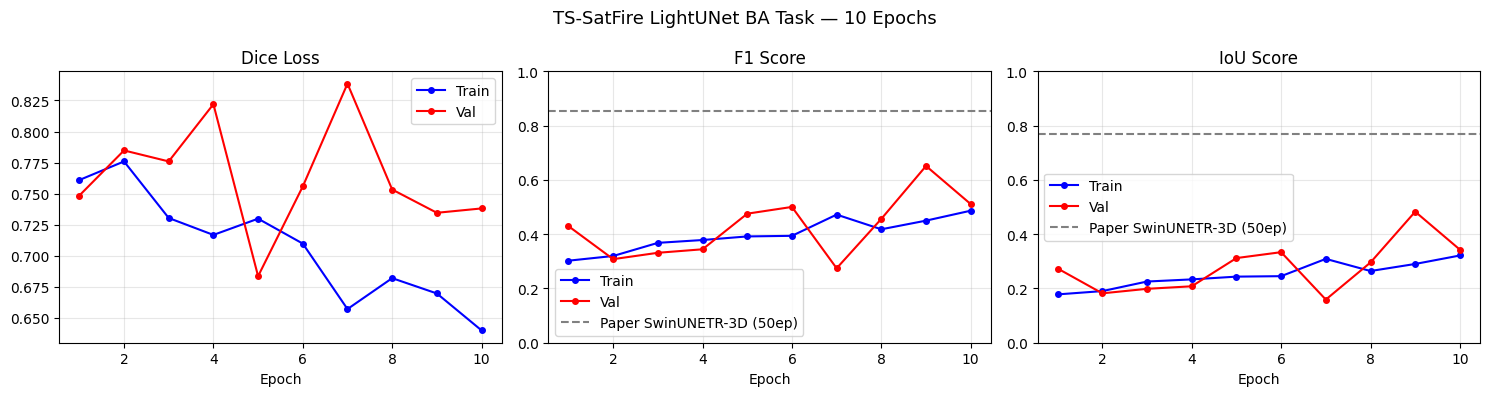

In [12]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val',   markersize=4)
axes[0].set_title('Dice Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_F1'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs, history['val_F1'],   'r-o', label='Val',   markersize=4)
axes[1].axhline(0.855, color='gray', linestyle='--', linewidth=1.5,
                label='Paper SwinUNETR-3D (50ep)')
axes[1].set_title('F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['train_IoU'], 'b-o', label='Train', markersize=4)
axes[2].plot(epochs, history['val_IoU'],   'r-o', label='Val',   markersize=4)
axes[2].axhline(0.768, color='gray', linestyle='--', linewidth=1.5,
                label='Paper SwinUNETR-3D (50ep)')
axes[2].set_title('IoU Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'TS-SatFire LightUNet BA Task — {NUM_EPOCHS} Epochs', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    path = os.path.join(OUTPUT_DIR, 'training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved {path}')
plt.show()

## Test Set Evaluation

Load the best checkpoint and evaluate on the 24 held-out 2021 fire events. Full-size images are padded to the nearest multiple of 16 before inference to avoid U-Net skip-connection size mismatches, then cropped back.

In [13]:
def pad_to_multiple(x, m=16):
    _, _, h, w = x.shape
    ph = (m - h % m) % m
    pw = (m - w % m) % m
    return F.pad(x, (0, pw, 0, ph)), h, w

# Load best checkpoint into a bare (non-DataParallel) model
eval_model = LightUNet(in_channels=IN_CHANNELS, out_channels=2, base_ch=BASE_CH)
state      = torch.load(CKPT_PATH, map_location=device)
eval_model.load_state_dict(state)
eval_model = eval_model.to(device).eval()
print(f'Loaded checkpoint: {CKPT_PATH}')

test_metrics = FireMetrics(threshold=0.5)
total_loss   = 0.0

# Optionally collect predictions for later visualization
all_preds = []  # list of (pred, gt, fire_id) dicts

bar = tqdm(test_loader, desc='Testing')
with torch.no_grad():
    for i, (x, y) in enumerate(bar):
        x, y   = x.to(device), y.to(device)
        x_pad, oh, ow = pad_to_multiple(x, 16)
        with make_autocast():
            logits = eval_model(x_pad)[:, :, :oh, :ow]
            loss   = criterion(logits, y)
        test_metrics.update(logits, y)
        total_loss += loss.item()
        rep = test_metrics.report()
        bar.set_postfix(F1=f'{rep["F1"]:.4f}', IoU=f'{rep["IoU"]:.4f}')

        if SAVE_PREDICTIONS and i < 50:
            prob = torch.softmax(logits.float(), dim=1)[0, 1].cpu().numpy()
            pred = (prob > 0.5).astype(np.uint8)
            gt   = y[0].cpu().numpy()
            all_preds.append({'pred': pred, 'gt': gt, 'prob': prob})

rep = test_metrics.report()
avg_loss = total_loss / len(test_loader)

print(f'\nTest Set Results  ({len(test_ds)} samples, {len(test_fires)} fires)')
print('=' * 45)
print(f'  F1      : {rep["F1"]:.4f}')
print(f'  IoU     : {rep["IoU"]:.4f}')
print(f'  TP      : {rep["TP"]:,}')
print(f'  FP      : {rep["FP"]:,}')
print(f'  FN      : {rep["FN"]:,}')
print(f'  Loss    : {avg_loss:.4f}')
print()
print(f'Paper baseline (SwinUNETR-3D, 50 epochs, full thermal aggregation):')
print(f'  F1  : 0.855   IoU : 0.768')

# Save test results
test_results = {
    'F1': rep['F1'], 'IoU': rep['IoU'], 'Loss': avg_loss,
    'TP': rep['TP'], 'FP': rep['FP'], 'FN': rep['FN'],
    'n_samples': len(test_ds), 'n_fires': len(test_fires),
}
with open(os.path.join(OUTPUT_DIR, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print(f'\nTest results saved to {OUTPUT_DIR}/test_results.json')

# Save predictions array for offline visualization
if SAVE_PREDICTIONS and all_preds:
    np.save(os.path.join(OUTPUT_DIR, 'test_predictions.npy'),
            np.array([p['pred'] for p in all_preds]))
    np.save(os.path.join(OUTPUT_DIR, 'test_groundtruth.npy'),
            np.array([p['gt']   for p in all_preds]))
    np.save(os.path.join(OUTPUT_DIR, 'test_probs.npy'),
            np.array([p['prob'] for p in all_preds]))
    print(f'Predictions saved (first {len(all_preds)} samples).')

Loaded checkpoint: /kaggle/working/lightunet_ba_best.pt


Testing:   0%|          | 0/202 [00:00<?, ?it/s]


Test Set Results  (202 samples, 24 fires)
  F1      : 0.6869
  IoU     : 0.5231
  TP      : 10,202,587
  FP      : 7,974,179
  FN      : 1,327,704
  Loss    : 0.7698

Paper baseline (SwinUNETR-3D, 50 epochs, full thermal aggregation):
  F1  : 0.855   IoU : 0.768

Test results saved to /kaggle/working/test_results.json


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (50, 596) + inhomogeneous part.

## Qualitative Results

False-colour composite (NIR / Red / MIR) alongside ground truth burned area and model prediction for 6 test samples. Per-sample F1 is shown below each prediction.

In [ ]:
CHANS_PER_STEP = IN_CHANNELS // TIME_STEPS  # 26

def make_rgb(x_np):
    offset = (TIME_STEPS - 1) * CHANS_PER_STEP  # last timestep
    channels = [x_np[offset + 1], x_np[offset + 0], x_np[offset + 3]]
    rgb = np.stack([c.astype(np.float32) for c in channels], axis=-1)
    for i in range(3):
        valid = rgb[..., i][np.isfinite(rgb[..., i])]
        if valid.size == 0:
            continue
        lo, hi = np.percentile(valid, [2, 98])
        rgb[..., i] = np.clip((rgb[..., i] - lo) / (hi - lo + 1e-6), 0, 1)
    return np.nan_to_num(rgb, nan=0.0)

def predict_full(x):
    if not isinstance(x, torch.Tensor):
        x = torch.from_numpy(x)
    x_t = x.unsqueeze(0).to(device)
    x_pad, oh, ow = pad_to_multiple(x_t, 16)
    with torch.no_grad():
        with make_autocast():
            logits = eval_model(x_pad)[:, :, :oh, :ow]
    prob = torch.softmax(logits.float(), dim=1)[0, 1].cpu().numpy()
    return (prob > 0.5).astype(np.uint8), prob

N_VIZ = 6
indices = np.linspace(0, len(test_ds) - 1, N_VIZ, dtype=int)

fig, axes = plt.subplots(N_VIZ, 3, figsize=(13, N_VIZ * 4))
col_titles = ['False Colour (NIR / Red / MIR)', 'Ground Truth BA', 'Predicted BA']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=8)

for row, idx in enumerate(indices):
    x, y  = test_ds[idx]
    pred, prob = predict_full(x)
    x_np  = x.numpy()
    y_np  = y.numpy()
    rgb   = make_rgb(x_np)

    axes[row, 0].imshow(rgb)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(y_np, cmap='Reds', vmin=0, vmax=1)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(pred, cmap='Reds', vmin=0, vmax=1)
    axes[row, 2].axis('off')

    tp = int(np.sum((pred == 1) & (y_np == 1)))
    fp = int(np.sum((pred == 1) & (y_np == 0)))
    fn = int(np.sum((pred == 0) & (y_np == 1)))
    f1_val = 2 * tp / (2 * tp + fp + fn + 1e-6)
    pct    = 100 * y_np.mean()
    axes[row, 2].set_xlabel(f'F1 = {f1_val:.3f}   burned = {pct:.2f}%',
                             fontsize=9, labelpad=4)

red_patch   = mpatches.Patch(color='darkred', label='Burned area')
white_patch = mpatches.Patch(facecolor='white', edgecolor='gray', label='Background')
fig.legend(handles=[red_patch, white_patch], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.005))

plt.suptitle(
    f'Burned Area Mapping — Qualitative Results\n'
    f'LightUNet {NUM_EPOCHS}-epoch demo  |  test F1={rep["F1"]:.4f}  IoU={rep["IoU"]:.4f}',
    fontsize=12, y=1.001
)
plt.tight_layout(rect=[0, 0.03, 1, 1])

if SAVE_FIGURES:
    path = os.path.join(OUTPUT_DIR, 'qualitative_results.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved {path}')
plt.show()

## Benchmark Comparison

Summary of this run versus the paper baselines (Table 3 in Zhao et al. 2025).

In [ ]:
results = {
    'Model'       : ['U-Net (2D)',   'Attn-UNet (2D)', 'UNETR-2D',
                     'SwinUNETR-2D', 'U-Net-3D',       'SwinUNETR-3D (paper)',
                     'LightUNet (this run)'],
    'Params (M)'  : [10.6, 31.7, 23.5, 25.2, 31.7, 33.2, n_params/1e6],
    'Input Days'  : [1, 1, 1, 1, 6, 6, TIME_STEPS],
    'F1 (BA)'     : [0.789, 0.793, 0.837, 0.829, 0.834, 0.855, rep['F1']],
    'IoU (BA)'    : [0.676, 0.687, 0.750, 0.733, 0.746, 0.768, rep['IoU']],
    'Epochs'      : [50, 50, 50, 50, 50, 50, NUM_EPOCHS],
}
cmp_df = pd.DataFrame(results)
cmp_df['Params (M)'] = cmp_df['Params (M)'].round(1)
cmp_df['F1 (BA)']    = cmp_df['F1 (BA)'].round(4)
cmp_df['IoU (BA)']   = cmp_df['IoU (BA)'].round(4)

print(cmp_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#90CAF9'] * 6 + ['#E57373']
labels = cmp_df['Model']
x_pos  = np.arange(len(labels))

for ax, metric in zip(axes, ['F1 (BA)', 'IoU (BA)']):
    bars = ax.bar(x_pos, cmp_df[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'Burned Area {metric}')
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, cmp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

blue_patch = mpatches.Patch(color='#90CAF9', label='Paper baselines (50 epochs)')
red_patch  = mpatches.Patch(color='#E57373', label=f'This run ({NUM_EPOCHS} epochs)')
fig.legend(handles=[blue_patch, red_patch], loc='upper right', fontsize=9)
plt.suptitle('Burned Area Mapping — Model Comparison', fontsize=13)
plt.tight_layout()

if SAVE_FIGURES:
    path = os.path.join(OUTPUT_DIR, 'benchmark_comparison.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved {path}')
plt.show()

## Saved Outputs

All files needed for offline inference and visualization are listed below. These persist after the notebook session closes.

In [ ]:
print('Outputs saved to:', OUTPUT_DIR)
print('=' * 55)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    unit  = 'KB' if size < 1024**2 else 'MB'
    val   = size / 1024 if unit == 'KB' else size / 1024**2
    print(f'  {fname:<40}  {val:6.1f} {unit}')
print()
print('Key files:')
print(f'  {CKPT_PATH}     -- best model weights (load with LightUNet)')
print(f'  {STATS_PATH}   -- normalisation stats (means, stds arrays)')
print(f'  {META_PATH}    -- run config and split info')
print(f'  history.json           -- per-epoch training metrics')
print(f'  test_results.json      -- final F1, IoU, TP/FP/FN')
print(f'  test_predictions.npy   -- binary predictions (first 50 test samples)')
print(f'  test_groundtruth.npy   -- ground truth masks (first 50 test samples)')
print(f'  test_probs.npy         -- raw fire probabilities (first 50 test samples)')